<a href="https://colab.research.google.com/github/spencer18001/Practical-Deep-Learning/blob/main/08_autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%capture
!mkdir -p miniai
!wget -O miniai/datasets.py https://raw.githubusercontent.com/fastai/course22p2/master/miniai/datasets.py
!wget -O miniai/training.py https://raw.githubusercontent.com/fastai/course22p2/master/miniai/training.py
!wget -O miniai/conv.py https://raw.githubusercontent.com/fastai/course22p2/master/miniai/conv.py
!pip install datasets

# Autoencoders

In [2]:
import pickle,gzip,math,os,time,shutil,torch,matplotlib as mpl,numpy as np,matplotlib.pyplot as plt
import fastcore.all as fc
from collections.abc import Mapping
from pathlib import Path
from operator import attrgetter,itemgetter
from functools import partial

from torch import tensor,nn,optim
from torch.utils.data import DataLoader,default_collate
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from datasets import load_dataset,load_dataset_builder

from fastprogress import progress_bar,master_bar
from miniai.datasets import *
from miniai.training import *
from miniai.conv import *

In [3]:
from fastcore.test import test_close

torch.set_printoptions(precision=2, linewidth=140, sci_mode=False)
torch.manual_seed(1)
mpl.rcParams['image.cmap'] = 'gray'

import logging
logging.disable(logging.WARNING)

## Data

In [4]:
x,y = 'image','label'
name = "fashion_mnist"
dsd = load_dataset(name, verification_mode="no_checks")
# dsd = load_dataset(name, ignore_verifications=True)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/9.02k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/30.9M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/5.18M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [5]:
@inplace
def transformi(b): b[x] = [TF.to_tensor(o) for o in b[x]]

In [6]:
bs = 256
tds = dsd.with_transform(transformi)

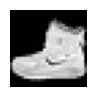

In [7]:
ds = tds['train']
img = ds[0]['image']
show_image(img, figsize=(1,1));

we will create our collation
function, collating the dictionary
for that data set

In [8]:
cf = collate_dict(ds)

In [9]:
def collate_(b): return to_device(cf(b))
def data_loaders(dsd, bs, **kwargs): return {k:DataLoader(v, bs, **kwargs) for k,v in dsd.items()}
# def data_loaders(dsd, bs, **kwargs): return {k:DataLoader(v, bs, num_workers=8, **kwargs) for k,v in dsd.items()}

In [10]:
dls = data_loaders(tds, bs, collate_fn=collate_)

In [11]:
dt = dls['train']
dv = dls['test']

xb,yb = next(iter(dt))

使用
```python
torch.multiprocessing.set_start_method('spawn')
```
會報錯

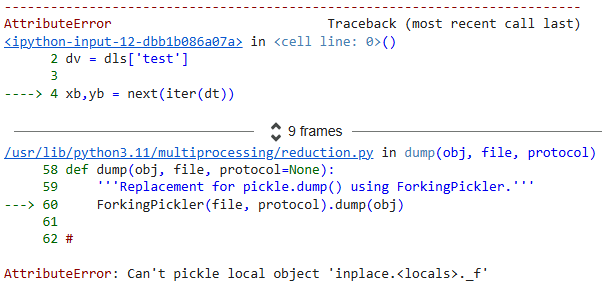

使用 `num_workers=8` 會報錯

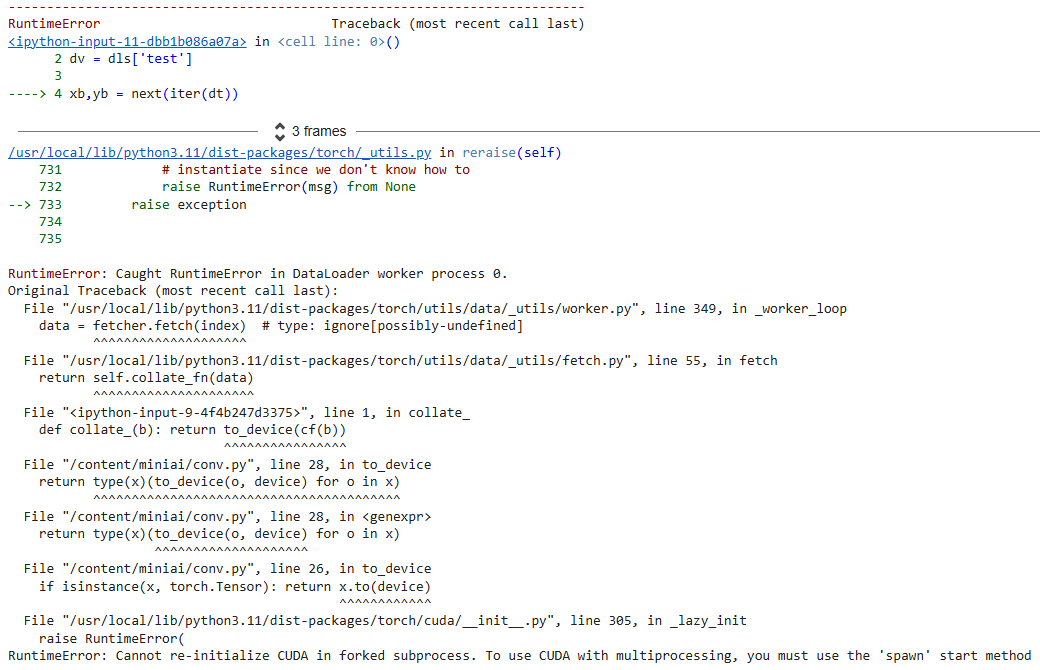

In [12]:
labels = ds.features[y].names

In [13]:
labels

['T - shirt / top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [14]:
lbl_getter = itemgetter(*yb[:16])
titles = lbl_getter(labels)

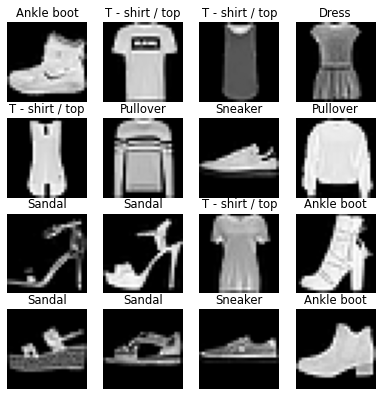

In [15]:
mpl.rcParams['figure.dpi'] = 70
show_images(xb[:16], imsize=1.7, titles=titles)

## Warmup - classify

In [16]:
from torch import optim

bs = 256
lr = 0.4

In [17]:
cnn = nn.Sequential(
    conv(1 ,4),            #14x14
    conv(4 ,8),            #7x7
    conv(8 ,16),           #4x4
    conv(16,16),           #2x2
    conv(16,10, act=False),
    nn.Flatten()).to(def_device)

In [18]:
opt = optim.SGD(cnn.parameters(), lr=lr)
loss,acc = fit(5, cnn, F.cross_entropy, opt, dt, dv)

0 0.8648017638206482 0.6828
1 0.5506875455856324 0.8046
2 0.4794714212179184 0.8261
3 0.457850971531868 0.835
4 0.4239735624790192 0.848


In [19]:
dsd['train'][0]

{'image': <PIL.PngImagePlugin.PngImageFile image mode=L size=28x28>,
 'label': 9}

## Autoencoder

In [20]:
def deconv(ni, nf, ks=3, act=True):
    layers = [nn.UpsamplingNearest2d(scale_factor=2),
              nn.Conv2d(ni, nf, stride=1, kernel_size=ks, padding=ks//2)]
    if act: layers.append(nn.ReLU())
    return nn.Sequential(*layers)

In [21]:
def eval(model, loss_func, valid_dl, epoch=0):
    model.eval()
    with torch.no_grad():
        tot_loss,count = 0.,0
        for xb,_ in valid_dl:
            pred = model(xb)
            n = len(xb)
            count += n
            tot_loss += loss_func(pred,xb).item()*n
    print(epoch, f'{tot_loss/count:.3f}')

In [22]:
def fit(epochs, model, loss_func, opt, train_dl, valid_dl):
    for epoch in range(epochs):
        model.train()
        for xb,_ in train_dl:
            loss = loss_func(model(xb), xb) # a big difference we've got here now is that our loss function is being applied to the output of the model and itself
            loss.backward()
            opt.step()
            opt.zero_grad()
        eval(model, loss_func, valid_dl, epoch)

In [23]:
ae = nn.Sequential(   #28x28
    nn.ZeroPad2d(2),  #32x32
    conv(1,2),        #16x16
    conv(2,4),        #8x8
#     conv(4,8),        #4x4
#     deconv(8,4),      #8x8
    deconv(4,2),      #16x16
    deconv(2,1, act=False), #32x32
    nn.ZeroPad2d(-2), #28x28
    nn.Sigmoid() # force everything to go between 0 and 1
).to(def_device)

In [24]:
eval(ae, F.mse_loss, dv)

0 0.182


In [25]:
opt = optim.SGD(ae.parameters(), lr=0.01)
fit(5, ae, F.mse_loss, opt, dt, dv)

0 0.154
1 0.139
2 0.130
3 0.126
4 0.125


In [26]:
opt = optim.SGD(ae.parameters(), lr=0.1)
fit(5, ae, F.mse_loss, opt, dt, dv)

0 0.125
1 0.124
2 0.124
3 0.124
4 0.124


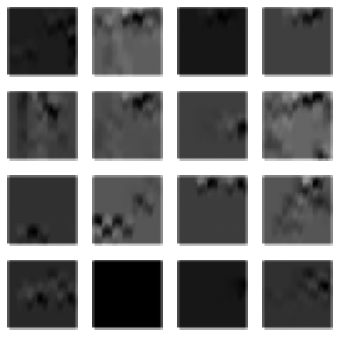

In [27]:
p = ae(xb)
show_images(p[:16].data.cpu(), imsize=1.5)

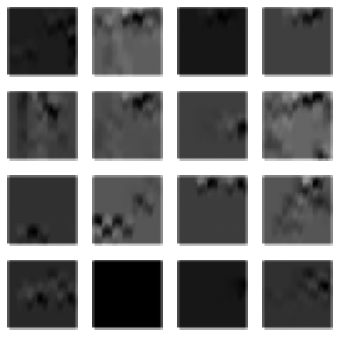

In [28]:
p = ae(xb)
show_images(p[:16].data.cpu(), imsize=1.5)

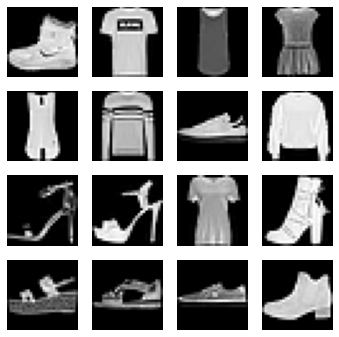

In [29]:
show_images(xb[:16].data.cpu(), imsize=1.5)